In [26]:
import torch
import torch.nn as nn
# from torchvision import models
from torchvision import transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from captum.attr import visualization as viz

# import onnxruntime as ort
import onnx
from onnx2pytorch import ConvertModel

# from tensorflow import keras
# import keras
import os

os.sys.path.append(os.path.dirname(os.path.abspath('.')))

from util import model_utils
from util.attribution_methods import saliencyMethods as attr
from util.attribution_methods import GIGBuilder as GIG_Builder
from util.attribution_methods import AGI as AGI

# TODO: export keras/tensorflow ultrasound gesture classifier model
# TODO: import keras/tensorflow ultrasound gesture classifier model here
# model = models.resnet101(weights = "ResNet101_Weights.IMAGENET1K_V2")
# model = model.eval()
# model.to("cuda:0")

# load keras/tensorflow ultrasound gesture classifier model here
keras_model_filepath: str = "/Users/rickgladwin/Code/u_of_hull/dissertation/Acoustic_Gesture_Recognition_v2/results/models/cnn/cnn_perp_subject_4_200_epochs_224px_20260804_124025.keras"

onnx_model_filepath = "/Users/rickgladwin/Code/u_of_hull/dissertation/Acoustic_Gesture_Recognition_v2/results/models/cnn/onnx/cnn_perp_subject_4_200_epochs_224px_20260804_124025.onnx"

# Import onnx model and convert to a PyTorch model that can be used with torchvision code
print(f"Loading model from: {onnx_model_filepath}\nand converting to PyTorch...")
onnx_model = onnx.load(onnx_model_filepath)
# model = ConvertModel(onnx_model, export_input=True, export_output=True)
# convert onnx model to pytorch model
model = ConvertModel(onnx_model)
# Set the model in evaluation mode (prevents dropout during inference if applicable)
model.eval()

# Get ONNX prediction
# print(f"Loading model from: {onnx_model_filepath}...")
# ort_sess = ort.InferenceSession(onnx_model_filepath)
# onnx_input_name = ort_sess.get_inputs()[0].name


# onnx_pred = ort_sess.run(None, {"input_tensor": dummy_input})[0]
# onnx_pred = ort_sess.run(None, {"input_tensor": test_image})[0]

learning_rate = 1e-5
input_shape = (224, 224, 1)
num_classes = 12

# print(f"Loading model from: {ultrasound_model_filepath}...")
# model = keras.models.load_model(ultrasound_model_filepath, compile=False)
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
#     loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
# )

# standard image resize dimension for ResNet
img_hw = 224

# transforms for IG, LIG, and IDG
transform = transforms.Compose([
     transforms.Resize((img_hw, img_hw)),
     transforms.CenterCrop(img_hw),
     transforms.ToTensor()
])

# standard ImageNet normalization for IG, LIG, and IDG
transform_normalize = transforms.Normalize(
     mean=[0.485, 0.456, 0.406],
     std=[0.229, 0.224, 0.225]
)

# transforms and normalization for GIG and AGI
resize = transforms.Resize((img_hw, img_hw))
crop = transforms.CenterCrop(img_hw)
# use this version to normalize an image with three channels (RGB)
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
# use this version to normalize an image with one channel (grayscale)
normalize_single_channel = transforms.Normalize(0.485, 0.229)
# normalize ultrasound images for the onnx loaded model
to_tensor = transforms.ToTensor()

# color map for Captum attribution visualization
default_cmap = LinearSegmentedColormap.from_list('custom blue',  [(0, '#ffffff'), (0.25, '#0000ff'), (1, '#0000ff')], N = 256)  

# TODO: address this warning:
# /Users/rickgladwin/Code/u_of_hull/dissertation/Integrated-Decision-Gradients/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
# import pynvml  # type: ignore[import]
# /Users/rickgladwin/Code/u_of_hull/dissertation/Integrated-Decision-Gradients/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
# from .autonotebook import tqdm as notebook_tqdm

Loading model from: /Users/rickgladwin/Code/u_of_hull/dissertation/Acoustic_Gesture_Recognition_v2/results/models/cnn/onnx/cnn_perp_subject_4_200_epochs_224px_20260804_124025.onnx
and converting to PyTorch...


<h1>Load an image and get the class</h1>

In [27]:
import tensorflow as tf

if False:
    # copied from Acoustic_Gesture_Recognition_v2.ultrasound_gesture_cnn_classification.py
    def load_subject_arrays(root: str, mode: str, subject: str, image_size: int):
        """
        Loads and preprocesses ultrasound data for training and testing. This function handles loading of data
        from disk, ensures data consistency, resizes images, normalizes the data, and returns the processed
        datasets along with the number of classes. It is specifically used for preparing ultrasound images for
        machine learning tasks, such as classification or segmentation.
    
        Parameters:
        root: str
            The root directory containing the dataset.
        mode: str
            The mode of data capture, one of ["mirror", "perp"], depending on the orientation of the ultrasound probe.
        subject: str
            Identifier of the subject whose data is to be loaded, one of ["Subject_1", "Subject_2", "Subject_3", "Subject_4", "Subject_5", "Subject_6"].
        image_size: int
            Desired width and height for image resizing. The function assumes a square dimension.
    
        Returns:
        tuple
            A tuple consisting of:
            - (x_train, y_train): Processed training dataset (features, labels).
            - (x_test, y_test): Processed testing dataset (features, labels).
            - num_classes: The total number of unique gesture classes in the dataset (12, for the 2025 mirror/perp dataset).
        """
    
        # example folder path to data:
        # /home/username/ultrasound_gesture_data/mirror/Subject_1/
        d = os.path.join(root, mode, subject)
        x_train = np.load(os.path.join(d, "X_m_train.npy"))
        x_test  = np.load(os.path.join(d, "X_m_test.npy"))
        y_train: np.ndarray = np.load(os.path.join(d, "y_m_train.npy"))
        y_test: np.ndarray  = np.load(os.path.join(d, "y_m_test.npy"))
    
        y_train = y_train.astype(np.int64).ravel()
        y_test  = y_test.astype(np.int64).ravel()
    
        # Ensure channel dim (N, H, W, 1)
        if x_train.ndim == 3: x_train = x_train[..., np.newaxis]
        if x_test.ndim  == 3: x_test  = x_test[..., np.newaxis]
    
        # Resize to image_size (keeps your ViT/CNN parity if you want 320)
        # TODO: look at converting to tensors that can be used with MPS optimization
        x_train = tf.image.resize(tf.convert_to_tensor(x_train), (image_size, image_size)).numpy()
        x_test  = tf.image.resize(tf.convert_to_tensor(x_test ), (image_size, image_size)).numpy()
    
        # Normalize to [0,1]
        if x_train.dtype != np.float32:
            x_train = x_train.astype("float32"); x_test = x_test.astype("float32")
        maxv = max(float(x_train.max()), 1.0)
        x_train /= maxv; x_test /= maxv
    
        class_count = int(max(y_train.max(), y_test.max()) + 1)
        return (x_train, y_train), (x_test, y_test), class_count


Image shape: torch.Size([1, 224, 224])
Image dtype: torch.float32
Image max: 0.9921568632125854
Unsqueezed shape: torch.Size([1, 1, 224, 224])
CUDA available:  False
MPS available:   True
Device name:     mps
target_class for example image img/ultrasound_subject_4_gesture_0_x_test_0_example.png: 0
name for target_class 0: IndFlex
model_utils.getPrediction():
88.843315 IndFlex


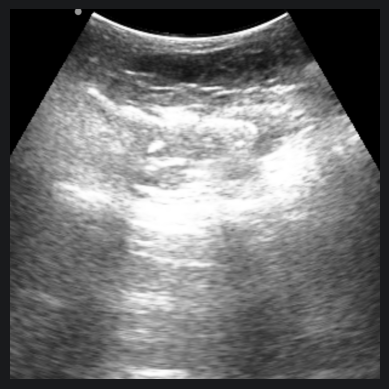

In [30]:
from PIL.ImageFile import ImageFile

# TODO: import example images from each gesture class
# TODO: get the class for each image
# image_path = "img/jet.jpg"
# img = Image.open(image_path)

# image_path = "img/ultrasound_subject_4_gesture_0_example.png"
image_path = "img/ultrasound_subject_4_gesture_0_x_test_0_example.png"
img: ImageFile = Image.open(image_path, formats=["PNG"])

trans_img = transform(img)
print(f"Image shape: {trans_img.shape}")
print(f"Image dtype: {trans_img.dtype}")
print(f"Image max: {trans_img.max()}")

# single sample shapes in PyTorch are torch.Size([channels, height, width])
# input_img = normalize(trans_img)
image_channels = trans_img.shape[0] # 1 for grayscale, 3 for RGB

# input_img = normalize_single_channel(trans_img)
# NOTE: transform(img) already includes transforms.ToTensor()
# input_img = to_tensor(trans_img)
# print(f"Normalized shape: {input_img.shape}")
# print(f"Normalized image max: {input_img.max()}")
# print(f"Normalized image dtype: {input_img.dtype}")
# input_img = input_img.unsqueeze(0)
input_img = trans_img.unsqueeze(0)
print(f"Unsqueezed shape: {input_img.shape}")
# example unsqueezed shape: torch.Size([1, 1, 224, 224])
# PyTorch uses NCHW format, so this represents torch.Size([batch, channels, height, width])

# check available devices
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"MPS available:   {torch.backends.mps.is_available()}")
print(f"Device name:     {'mps' if torch.backends.mps.is_available() else 'cpu'}")

# device = "cuda:0"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# override device to cpu
# TODO: after getting this to run on CPU, reintroduce MPS
device = "cpu"

# configure the model for the device
model.to(device)

# TODO: check model.to(device) and tensor = tensor.to(device)

# copied from tensorflow_image_classifier_explainability/integrated_gradients_ultrasound.ipynb
# gesture class index (0-11) and class shortnames
gesture_class_index_and_shortnames: list[tuple[int, str]] = [
    (0, "IndFlex"),
    (1, "MidFlex"),
    (2, "RinFlex"),
    (3, "PinFlex"),
    (4, "IndPinch"),
    (5, "IndMidPinch"),
    (6, "IndMidRinPinch"),
    (7, "AllPinch"),
    (8, "MidRinPinch"),
    (9, "Fist"),
    (10, "Hook"),
    (11, "Open"),
]

classes = [shortname for _, shortname in gesture_class_index_and_shortnames]

target_class = model_utils.getClass(input_img, model, device)
print(f"target_class for example image {image_path}: {target_class}")
# open the class list so the detected class string can be returned for printing
# with open('../util/class_maps/ImageNet/imagenet_classes.txt') as f:
#     classes = [line.strip() for line in f.readlines()]
name = classes[target_class]
print(f"name for target_class {target_class}: {name}")
print(f"model_utils.getPrediction():")
print(model_utils.getPrediction(input_img, model, device, target_class)[0] * 100, name)

plt.axis("off")

# use gray colormap for grayscale (single channel) images
if image_channels == 1:
    img_colormap = plt.get_cmap('gray')
else:
    img_colormap = None

plt.imshow(img, cmap=img_colormap)
plt.show()

<h1>Generate attributions</h1>

In [16]:
steps = 50
batch_size = 25
baseline = 0

In [17]:
# alpha star = 1, plain IG attribution
ig = attr.IG(input_img, model, steps, batch_size, 1, 0, device, target_class)

RuntimeError: The expanded size of the tensor (1) must match the existing size (25) at non-singleton dimension 1.  Target sizes: [25, 1, 224, 224].  Tensor sizes: [25, 224, 224]

In [5]:
# alpha star = 0.9, Left IG attribution
lig = attr.IG(input_img, model, steps, batch_size, .9, 0, device, target_class)

In [6]:
# get integrated decision gradients attribution
# TODO: try running this with a loaded keras model
#  OR make a version of attr.IDG() that will work with a loaded keras model
idg = attr.IDG(input_img, model, steps, batch_size, 0, device, target_class)

In [7]:
call_model_args = {'class_idx_str': target_class.item()}
guided_ig = GIG_Builder.GuidedIG()
baseline = torch.zeros_like(input_img)
gig = guided_ig.GetMask(input_img, model, device, GIG_Builder.call_model_function, call_model_args, x_baseline=baseline, x_steps=50, max_dist=1.0, fraction=0.5)

In [8]:
epsilon = 0.05
topk = 1
max_iter = 20
agi_img = AGI.LoadImage(image_path, resize, crop)
agi_img = agi_img.astype(np.float32)

# cast image tensor to device
# agi_img = torch.from_numpy(agi_img).to(device)
agi_img = torch.from_numpy(agi_img).to("cpu")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
norm_layer = AGI.Normalize(mean, std)
modified_model = nn.Sequential(norm_layer, model).to(device)        
selected_ids = range(0, 999, int(1000 / topk))

_, _, agi = AGI.test(modified_model, device, agi_img, epsilon, topk, selected_ids, max_iter)

# perform AGI thresholding 
percentile = 80
upperbound = 99
hm = agi
hm = np.mean(hm, axis=0)
q = np.percentile(hm, percentile)
u = np.percentile(hm, upperbound)
hm[hm<q] = q
hm[hm>u] = u
hm = (hm-q)/(u-q)

# AGI attribution
agi = np.reshape(hm, (img_hw, img_hw, 1))

<h1>Visualize the attributions </h1>

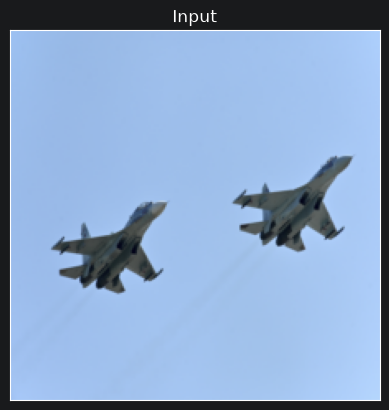

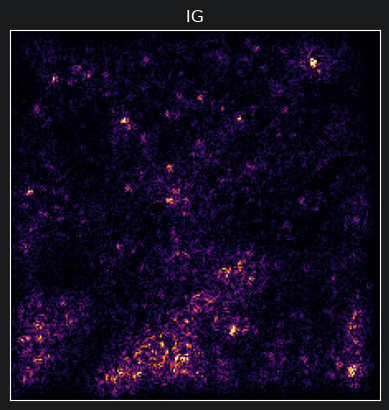

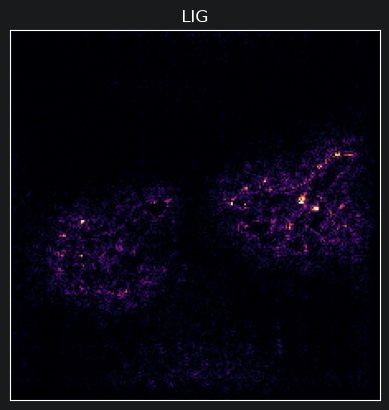

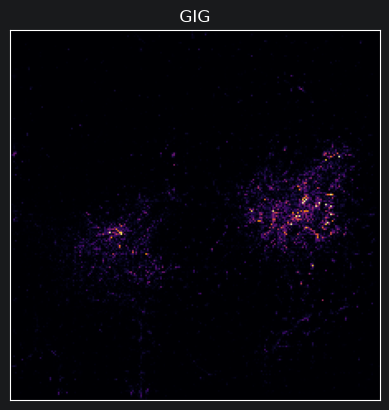

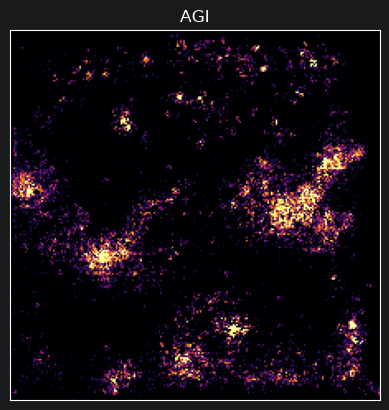

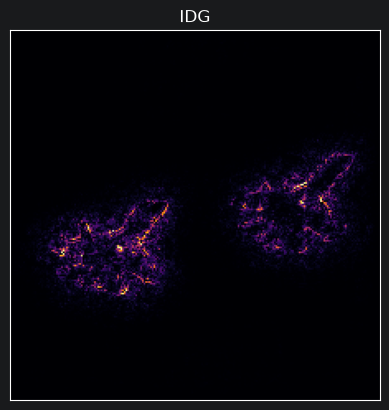

In [10]:
# transform the [C, H, W] image and attributions to [H, W, C] for display
# TODO: make sure the .cpu() call makes sense here if using another device
img_print = np.transpose(trans_img.squeeze().detach().cpu().numpy(), (1, 2, 0))
ig_print = np.transpose(ig.squeeze().detach().cpu().numpy(), (1,2,0))
lig_print = np.transpose(lig.squeeze().detach().cpu().numpy(), (1,2,0))
idg_print = np.transpose(idg.squeeze().detach().cpu().numpy(), (1,2,0))
gig_print = np.transpose(gig.squeeze().detach().cpu().numpy(), (1, 2, 0))
agi_print = agi

# use 0 to 100 luminosity colormap
default_cmap = plt.get_cmap("inferno")

# TODO: make a loop that creates a grid of multiple classes and IG techniques

# fig, _ = viz.visualize_image_attr(None,
fig, _ = viz.visualize_image_attr(img_print,
                            img_print,
                            method="original_image",
                            title="Input",
                            plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(ig_print,
                            img_print,
                            method='heat_map',
                            title="IG",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(lig_print,
                            img_print,
                            method='heat_map',
                            title="LIG",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))


fig, _ = viz.visualize_image_attr(gig_print,
                            img_print,
                            method='heat_map',
                            title="GIG",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))


fig, _ = viz.visualize_image_attr(agi_print,
                            img_print,
                            method='heat_map',
                            title="AGI",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))


fig, _ = viz.visualize_image_attr(idg_print,
                            img_print,
                            method='heat_map',
                            title="IDG",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))